## Problem Statement:
Building end-to-end model to detect and transcribe historical Spanish printed text with high accuracy.

To address this problem, a **three-stage OCR pipeline** has been implemented.The stages are as follows:
1. DBNet for text detection
2. CRNN for text recognition.
3. LLM for output refining.

In [79]:
# Importing necessary libraries:
import sys
import fitz
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
from tqdm import tqdm
from doctr.io import DocumentFile
import re
import random
import albumentations as A
import torch
import numpy as np
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.nn as nn
from IPython.display import FileLink
import ollama
import time

## Stage 1- Text Detection:

### Step 1- Converting image files from pdf to jpg:

In [4]:
#Listing paths of the saved pdfs on my local device.
path1=r"C:\Users\91861\Downloads\Print_Test_Files\Print\PORCONES.23.5 - 1628.pdf"
path2=r"C:\Users\91861\Downloads\Print_Test_Files\Print\PORCONES.748.6 – 1650.pdf"
path3=r"C:\Users\91861\Downloads\Print_Test_Files\Print\Guardiola - Tratado nobleza.pdf"
path4=r"C:\Users\91861\Downloads\Print_Test_Files\Print\PORCONES.228.38 – 1646.pdf"
path5=r"C:\Users\91861\Downloads\Print_Test_Files\Print\Covarrubias - Tesoro lengua.pdf"
path6=r"C:\Users\91861\Downloads\Print_Test_Files\Print\Buendia - Instruccion.pdf"
path_list=[path1,path2,path3,path4,path5,path6]

In [5]:
for i in range(len(path_list)):
    doc=fitz.open(path_list[i])
    print(doc.page_count) #Printing no of pages for each Pdf (sanity check)

12
26
311
23
990
33


In [7]:
#Code snippet to open a pdf from it's storage path and read it using the fitz module:
doc1=fitz.open(path1)
doc1.page_count

12

In [12]:
base_output_path=r"C:\Users\91861\Desktop\GSOC 26\Human_AI\RenAIssance\Printed_Text"
docu_list=["pdf1","pdf2","pdf3","pdf4","pdf5","pdf6"]

In [80]:
#NO NEED TO RERUN- Jpegs already saved
#Converting all pdfs into jpegs and storing then in respective folders:

for i in range(len(path_list)):
    folder_path = os.path.join(base_output_path, docu_list[i])
    os.makedirs(folder_path, exist_ok=True)
    doc=fitz.open(path_list[i])
    pg_no=doc.page_count
    
    for j in range(pg_no):
        page=doc.load_page(j)
        pix=page.get_pixmap(dpi=100)
        output_path = os.path.join(folder_path, f"page-{j+1}.jpg")
        pix.save(output_path, jpg_quality=90)
        
    doc.close()  

'\nfor i in range(len(path_list)):\n    folder_path = os.path.join(base_output_path, docu_list[i])\n    os.makedirs(folder_path, exist_ok=True)\n    doc=fitz.open(path_list[i])\n    pg_no=doc.page_count\n    \n    for j in range(pg_no):\n        page=doc.load_page(j)\n        pix=page.get_pixmap(dpi=100)\n        output_path = os.path.join(folder_path, f"page-{j+1}.jpg")\n        pix.save(output_path, jpg_quality=90)\n        \n    doc.close()  '

The above code converts the pdfs into jpg files.Now, the next step is text detection on individual page images.

Ground Truth Labels are available for the following page numbers:

1. pdf1- *PORCONES.23.5* - 1628-Pg 1,2,3,4
2. pdf2- *PORCONES.748.6* – 1650-Pg 1,2,3,4
3. pdf3- *Guardiola - Tratado nobleza* - Pg 12,13,14
4. pdf4- *PORCONES.228.38 – 1646* - Pg 1,2,3,4,5
5. pdf5- *Covarrubias - Tesoro lengua* - Pg 7,8,9
6. pdf6- *Buendia - Instruccion* - pg2,3,4

In [81]:
#Storing Page nos for which ground truth labels available for each Pdf as a list:

pages_to_process=[[x for x in range(1,5)],[x for x in range(1,5)],[x for x in range(12,15)],[x for x in range(1,6)],[x for x in range(7,10)],[x for x in range(2,5)]]
print(pages_to_process)

pdf_gt_page_counts=["4","4","3","5","3","3"]

[[1, 2, 3, 4], [1, 2, 3, 4], [12, 13, 14], [1, 2, 3, 4, 5], [7, 8, 9], [2, 3, 4]]


## Step 2- Text Detection:

### Model Used: Pre-Trained DBNet Model

**Basic Idea :** 
DBNet approaches scene text detection as a pixel-wise segmentation (into text/ not text) problem. Given an input image, a convolutional backbone (e.g., ResNet) is used to extract deep feature maps. A segmentation head is then used to predict a probability map where each value corrosponding to a pixel  represents the likelihood of the belonging to a text region.

Instead of using a fixed threshold (like more traditional approaches) to convert this probability map into a binary mask, DBNet introduces the concept of a learnable threshold map.This allows the model to adaptively determine decision boundaries at each pixel location.

**Differrentiable Binarization:**
Traditional binarization applies a hard threshold- 

$$
B(x,y) =
\begin{cases}
1 & \text{if } P(x,y) > T(x,y) \\
0 & \text{otherwise}
\end{cases}
$$

However, this makes it non-differrentiable and thus non-trainable.

The innovation of the DBNet Model is the use of the following approximation:

$$
\hat{B}(x,y) = \sigma\big(k(P(x,y) - T(x,y))\big)
$$
This approximates hard thresholding while remaining differentiable, thus enabling gradients to flow through both the probability and threshold maps during training. This the complete model can be trained together.

**Reasons for Choosing DBNet:**
1. Works well with multi-oriented and curved text- In our use case, text may be non-horizontal/curved and handling these cases is crucial.
2. It shows strong performance on the standard scene text benchmarks.

**Reference** :  
Liao, M.; Wan, Z.; Yao, C.; Chen, K.; & Bai, X. (2019).  
*Real-time Scene Text Detection with Differentiable Binarization.*  
https://arxiv.org/abs/1911.08947



**Implementing DBNet Model:**

In [125]:
#Library used- DocTR:

from doctr.models import ocr_predictor #Importing pre-trained OCR model- only text detection functionality will be used.

model = ocr_predictor(pretrained=True) #loading a pretrained OCR pipeline

#First, implementing text detection on single page:
#path of Page 2 of Pdf1 saved on my system:
path=r"C:\Users\91861\Desktop\GSOC 26\Human_AI\RenAIssance\Printed_Text\pdf1\page-2.jpg"

doc = DocumentFile.from_images(path) #Converts image into DocTR’s internal format- doc object
result = model(doc) #Applying OCR to the doc object

In [46]:
#Printing coordinates of the first 4 detected bounding boxes:

page = result.pages[0] #Accessing 1st page in the result.pages list- here, it contains only 1 page.
for block in page.blocks: #Block= group of lines
    i=1
    for line in block.lines:
        while i<5:
            print(line.geometry) #line.geometry gives the bounding boxes of each line- format=((x_min, y_min), (x_max, y_max))
            i=i+1           #coordinates are normalized between 0 and 1- need to be multiplied by length and width later to give pixel bounding boxes

((np.float64(0.0615234375), np.float64(0.036458333333333315)), (np.float64(0.0732421875), np.float64(0.052083333333333315)))
((np.float64(0.0615234375), np.float64(0.036458333333333315)), (np.float64(0.0732421875), np.float64(0.052083333333333315)))
((np.float64(0.0615234375), np.float64(0.036458333333333315)), (np.float64(0.0732421875), np.float64(0.052083333333333315)))
((np.float64(0.0615234375), np.float64(0.036458333333333315)), (np.float64(0.0732421875), np.float64(0.052083333333333315)))


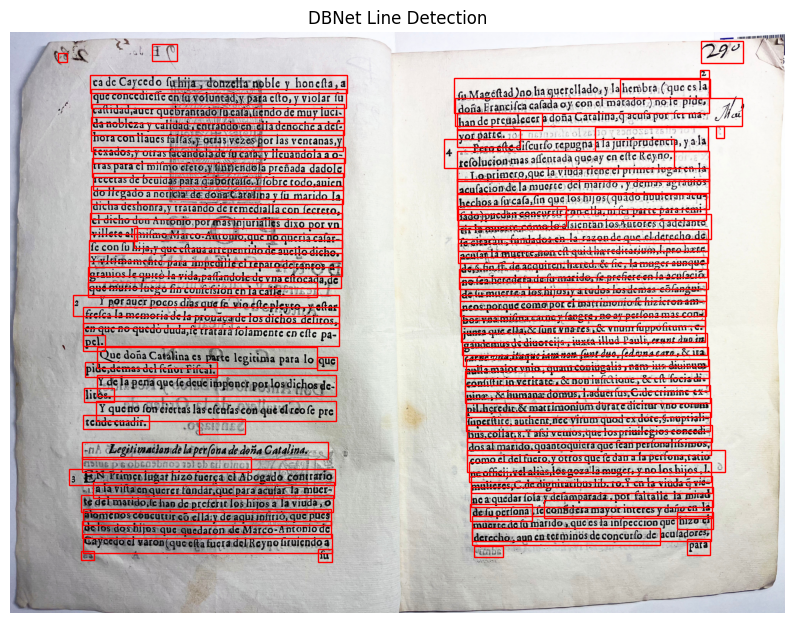

In [128]:
#Visualizing the detected bounding boxes on the Printed page image:

fig, ax = plt.subplots(figsize=(10, 15))
img = doc[0]
ax.imshow(img) 

h, w = img.shape[:2]

#Drawing bounding boxes using the coordinates in the image:
for block in page.blocks:
    for line in block.lines: 
        (x_min, y_min), (x_max, y_max) = line.geometry
    
        #calculating positions in the image from the normalized values using image height and width
        x_min *= w
        x_max *= w
        y_min *= h
        y_max *= h
        
        rect = patches.Rectangle(
            (x_min, y_min),# top left coordinates of bounding box- anchor point
            x_max - x_min,# width = Right boundary-Left boundary
            y_max - y_min,# height = Bottom boundary-Top boundary
            linewidth=1,
            edgecolor='red',
            facecolor='none'
        ) #creating the rectangular patch object- the bounding box
        
        ax.add_patch(rect) #adding the bounded box to the image

plt.title("DBNet Line Detection")
plt.axis('off')
plt.show()

### Step 3- Dataset Preparation:  
The model is able to satisfactory detect lines in the text as seen from the above image.  
So, we move forward with cropping the image following the bounding boxes and storing the individual cropped line images.These images will be the inputs  to be used for model training.

In [31]:
#Base directory for saving the line crops of Pdf1, pg2:

base_dir = r"C:\Users\91861\Desktop\GSOC 26\Human_AI\RenAIssance\Printed_Text\pdf1\line_crops_test"
os.makedirs(base_dir, exist_ok=True)

img = doc[0] 
h, w, _ = img.shape #Derieving image height and width

page = result.pages[0] #Derieving the results of OCR on the Page

line_id = 0

for block in page.blocks:
    for line in block.lines:
        
        (x_min, y_min), (x_max, y_max) = line.geometry
        
        x_min = int(x_min * w) 
        x_max = int(x_max * w)
        y_min = int(y_min * h)
        y_max = int(y_max * h)
        
        crop = img[y_min:y_max, x_min:x_max]
        save_path = os.path.join(base_dir, f"line_{line_id:04d}.jpg")
        
        cv2.imwrite(save_path, cv2.cvtColor(crop, cv2.COLOR_RGB2BGR))
        
        line_id += 1

print(line_id) #This is the number of lines extracted from the image.

Total lines extracted: 85


Next,for all pages of the Pdfs which have corrosponding ground truth labels, we repeat the process of generating bounding boxes, cropping the lines following the bounding boxes and saving the cropped images.

In [57]:
#NO NEED TO RERUN - Cropped line images already stored.

# Flattening total page count for a progress bar:
total_pages = sum(len(pages) for pages in pages_to_process)

#Setting base path:
base_root = r"C:\Users\91861\Desktop\GSOC 26\Human_AI\RenAIssance\Printed_Text"

not_done_log=[]

with tqdm(total=total_pages, desc="Processing Pages") as pbar:

    for pdf_index in range(6):

        pdf_name = f"pdf{pdf_index + 1}"
        pdf_folder = os.path.join(base_root, pdf_name)

        main_crop_folder = os.path.join(pdf_folder, "line_crops")
        os.makedirs(main_crop_folder, exist_ok=True)

        for page_number in pages_to_process[pdf_index]:

            image_path = os.path.join(pdf_folder, f"page-{page_number}.jpg")

            if not os.path.exists(image_path):
                pbar.update(1)
                not_done_log.append(f"Pdf: {pdf_name} , Pg No: {page_number} could not be processed")
                continue

            doc = DocumentFile.from_images(image_path)
            result = model(doc)

            img = doc[0]
            h, w, _ = img.shape
            page = result.pages[0]

            page_folder = os.path.join(main_crop_folder, f"page_{page_number}")
            os.makedirs(page_folder, exist_ok=True)

            line_id = 0

            for block in page.blocks:
                for line in block.lines:

                    (x_min, y_min), (x_max, y_max) = line.geometry

                    x_min = int(x_min * w)
                    x_max = int(x_max * w)
                    y_min = int(y_min * h)
                    y_max = int(y_max * h)

                    if x_max > x_min and y_max > y_min:

                        crop = img[y_min:y_max, x_min:x_max]

                        save_path = os.path.join(
                            page_folder,
                            f"line_{line_id:04d}.jpg")

                        cv2.imwrite(
                            save_path,
                            cv2.cvtColor(crop, cv2.COLOR_RGB2BGR))

                        line_id += 1

            pbar.update(1)


rocessing Pages: 100%|████████████████████████████████████████████████████████████████| 22/22 [02:20<00:00,  6.41s/it]

Preparing the ground truth labels (The Y variable values) for model training:

In [1]:
#NO NEED TO RERUN - Cropped line image labels already stored.

# Base path where all Ground Truth labels are stored as .txt files:
gt_folder = r"C:\Users\91861\Downloads"

#File naming structure of the ground truth text files - gt_i_j, where i=pdf no and j=page no

# Dictionary structure is used to store the gt text- nested dictionary
# ground_truth[pdf_no][page_no] = gt_text

ground_truth = {}

pattern = re.compile(r"gt_(\d+)_(\d+)\.txt")

for filename in os.listdir(gt_folder):    
    match = pattern.match(filename)
    
    if match:
        pdf_no = int(match.group(1))
        page_no = int(match.group(2))        
        file_path = os.path.join(gt_folder, filename)
        
        with open(file_path, "r", encoding="utf-8") as f:
            text = f.read().strip()
        
        if pdf_no not in ground_truth:
            ground_truth[pdf_no] = {}
        
        ground_truth[pdf_no][page_no] = text
print("Ground truths loaded successfully!")

Ground truths loaded successfully!


The input images consist of line level data.So, we split the ground truth text for each page line by line.

In [4]:
#NO NEED TO RERUN - Cropped line image labels already stored.

#The input images consist of line level data.So, we split the ground truth text for each page line by line and store it in the dictionary:
for pdf_no in ground_truth:
    for page_no in ground_truth[pdf_no]:
        
        full_text = ground_truth[pdf_no][page_no]
        
        # Splitting by line breaks and removing empty lines
        lines = [line.strip() for line in full_text.splitlines() if line.strip() != ""]
        
        ground_truth[pdf_no][page_no] = lines

#This will convert the transcripts into line level lists.

In [6]:
ground_truth[1][2][:10]    #Sanity Check

['ca de Caycedo su hija, donzella noble y honesta, a',
 'que concedielle en su voluntad, y para esto, y violar su',
 'castidad, aver quebrantado su casa, siendo de muy luci-',
 'da nobleza y calidad, entrando en ella denoche a des-',
 'hora con llaves falsas, y otras vezes por las ventanas, y',
 'texados, y otras sacandola de su casa, y llevandola a o-',
 'tras para el mismo efeto, y sintiendola preñada dadole',
 'recetas de bevidas para q abortasse. Y sobre todo, avien',
 'do llegado a noticia de doña Catalina y su marido la',
 'dicha deshonra, y tratando de remedialla con secreto,']

In [7]:
#NO NEED TO RERUN - Cropped line image labels already stored.

#Generating a file "labels" for each page that maps the cropped line images(ordered) to the corrosponding ground truth line texts.

base_root = r"C:\Users\91861\Desktop\GSOC 26\Human_AI\RenAIssance\Printed_Text"

for pdf_no in ground_truth:    
    pdf_folder = os.path.join(base_root, f"pdf{pdf_no}", "line_crops")    
    if not os.path.exists(pdf_folder):
        continue
    
    for page_no in ground_truth[pdf_no]:        
        page_folder = os.path.join(pdf_folder, f"page_{page_no}")        
        if not os.path.exists(page_folder):
            continue
        
        image_files = [
            f for f in os.listdir(page_folder)
            if f.lower().endswith(".jpg")]
        
        image_files.sort()      
        gt_lines = ground_truth[pdf_no][page_no]        
        max_len = max(len(image_files), len(gt_lines))        
        labels_path = os.path.join(page_folder, "labels.txt")
        
        with open(labels_path, "w", encoding="utf-8") as f:           
            for i in range(max_len):                
                img_name = image_files[i] if i < len(image_files) else ""
                gt_line = gt_lines[i] if i < len(gt_lines) else ""              
                f.write(f"{img_name}\t{gt_line}\n")

**Note:** This saves the images of text lines and line labels in files.I have manually removed some blank images and rearranged some files to form correct the (Cropped Line Image, ground Truth Line Text) pair mapping, for a few cases.  
Thus we have a dataset with **(Cropped Line Image, ground Truth Line Text)** pairs ready for training.


## Stage 2- CRNN Modelling:

### Step 4- Preparing Train, Validation, Test Data:  



Loading the complete dataset and shuffling it before splitting into Train- Validation- Test sets.  
**Dataset Shuffling** is done to prevent lines from only one/two pdfs appearing in the Validation/Test set and thus leading to incorrect accuracy metrics.

In [8]:
# Root directory containing the pdfs:
root_dir = r"C:\Users\91861\Desktop\GSOC 26\Human_AI\RenAIssance\Printed_Text"

dataset = []

for pdf_folder in os.listdir(root_dir):
    pdf_path = os.path.join(root_dir, pdf_folder)
    if not os.path.isdir(pdf_path):
        continue

    line_crops_path = os.path.join(pdf_path, "line_crops")
    if not os.path.exists(line_crops_path):
        continue
        
    for page_folder in os.listdir(line_crops_path):
        page_path = os.path.join(line_crops_path, page_folder)
        if not os.path.isdir(page_path):
            continue
        labels_file = os.path.join(page_path, "labels.txt")

        if not os.path.exists(labels_file):
            continue

        with open(labels_file, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()

                if not line:
                    continue

                img_name, text_label = line.split("\t")
                img_path = os.path.join(page_path, img_name)
                dataset.append((img_path, text_label))


# shuffling dataset:
random.shuffle(dataset)

# Sanity Check:
print("Total dataset size:", len(dataset))
print("Last 5 data points", dataset[:5])


Total dataset size: 836
Last 5 data points [('C:\\Users\\91861\\Desktop\\GSOC 26\\Human_AI\\RenAIssance\\Printed_Text\\pdf2\\line_crops\\page_1\\line_0045.jpg', 'firmat vivendus Farinac. De reo confes… convict. q. 81.'), ('C:\\Users\\91861\\Desktop\\GSOC 26\\Human_AI\\RenAIssance\\Printed_Text\\pdf1\\line_crops\\page_4\\line_0032.jpg', 'item ait, ff. de iniurijs: vbi vero, la ofensa es comun a'), ('C:\\Users\\91861\\Desktop\\GSOC 26\\Human_AI\\RenAIssance\\Printed_Text\\pdf4\\line_crops\\page_3\\line_0031.jpg', 'rederos contenidas en la relacion jurada, que dio,'), ('C:\\Users\\91861\\Desktop\\GSOC 26\\Human_AI\\RenAIssance\\Printed_Text\\pdf5\\line_crops\\page_9\\line_0032.jpg', 'bando evidentemente lo contrario dellos; y enseñando lo uno que'), ('C:\\Users\\91861\\Desktop\\GSOC 26\\Human_AI\\RenAIssance\\Printed_Text\\pdf2\\line_crops\\page_3\\line_0007.jpg', 'nir a casa de día, particularmente la noche que vinis-')]


### Train- Validation- Test split:

I am training on 90% of the dataset (As the dataset is very small, I am keeping as much data possible for better training) and allocating 5% each for Validation and Test Datasets.

In [9]:
from sklearn.model_selection import train_test_split

# First splitting into: train vs (test&val)
train_data, test_and_val_data = train_test_split(dataset,test_size=0.10,random_state=42)

# Second split: validation vs test
val_data, test_data = train_test_split(test_and_val_data,test_size=0.5,random_state=42)

# Printing dataset sizes
print("Train set size:", len(train_data))
print("Validation set size:", len(val_data))
print("Test set size:", len(test_data))

Train set size: 752
Validation set size: 42
Test set size: 42


### Step 5: Carrying out data augmentation on Training Data:  
Data augmentation prevents overfitting- It helps learn more robust features.  


In [47]:
#Creating a data augmentation pipeine:
train_transform = A.Compose([
    # 1. Image Rotation:
    A.Rotate(limit=2,#Randomly rotates the image--2° to +2°.
        border_mode=cv2.BORDER_CONSTANT,fill=255,#rotation creates empty space around the image, so filling it with white
        p=0.4), # 40% of images get rotated,

    # 2. Shifting and resizing image:
    A.ShiftScaleRotate(shift_limit=0.01, #shifting image vertically/horizontally- max of 1% of image height/width
        scale_limit=0.05, #scaling image a max of 5% up or down
        rotate_limit=0,border_mode=cv2.BORDER_CONSTANT,fill=255,p=0.4),

    # 3. Adjuting brightness/contrast:
    A.RandomBrightnessContrast(brightness_limit=0.2, #inc/ dec brigtness by max of 20%
        contrast_limit=0.2, #inc/ dec contrast by max of 20%
        p=0.5 #randomly applied to 1/2 of the images
    ),

    # 4. Adding Gaussian blur:
    A.GaussianBlur(blur_limit=(3,3),p=0.3), # blur applied on 30% of images.

    # 5. Adding Gaussian noise:
    A.GaussNoise(std_range=(0.02, 0.08),p=0.3), #adding random pixel noise.

    # 6. Adding slight elastic distortion (warping of the image).
    A.ElasticTransform(alpha=1,sigma=30,border_mode=cv2.BORDER_CONSTANT,fill=255,p=0.05)])

C:\Users\91861\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


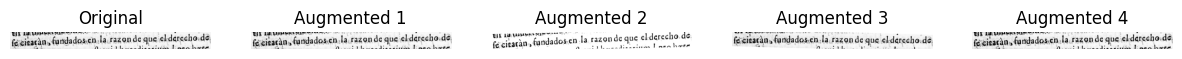

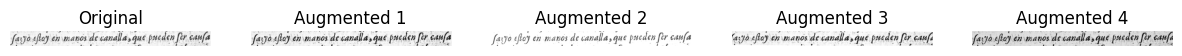

In [69]:
#Visualising the data augmentation results on 2 data points:

# picking first two images from the training dataset:
image_paths = [train_data[0][0], train_data[1][0]]

for path in image_paths:    
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE) #Loading image as grayscale.
    plt.figure(figsize=(15,3))
    
    plt.subplot(1,5,1)
    plt.imshow(img, cmap="gray")
    plt.title("Original")
    plt.axis("off")

    for i in range(4):
        augmented = train_transform(image=img)["image"] #generating augmentations
        plt.subplot(1,5,i+2)
        plt.imshow(augmented, cmap="gray")
        plt.title(f"Augmented {i+1}")
        plt.axis("off")

    plt.show()

The augmented images look realistic, so we are going to apply this pipeline to all images while training so that our model is trained on a larger and more varied dataset.

### Preparing Character Set:

CRNN Model carries out sequence prediction where each character predicted is a classification over all possible characters.So, first, we must define the Character Set.  
The final softmax layer in the Model will have (Character Set size +1[For Blank]) neurons- each neuron will corrospond to a character.


In [10]:
# Extracting character set from labels:
charset = set()

for _, label in dataset:
    for character in label:
        charset.add(character)

charset = sorted(list(charset))

print(charset)
print("Length of Character Set: ", len(charset))

[' ', '!', '&', '(', ')', ',', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'x', 'y', 'z', '§', 'Ñ', 'á', 'ç', 'é', 'í', 'ñ', 'ó', '–', '…']
Length of Character Set:  78


Thus, the last layer of the CRNN model will have 79 Neurons.

## Theory and Reasoning Behind Models/Frameworks Used:

### CRNN Model:  

**Basic Idea:**  
CRNN is a combination of:
1. DeepCNN
2. RNN(Deep Bi-Directional LSTM)
3. CTC Transcription layer

**Motivation: Why is traditional CNN not suitable for this task?**  

1. CNNs are effective for image classification tasks where the goal is to predict a single label for an input image. However, image-based text recognition requires prediction of a **sequence of labels** rather than a single label. 
2. CNN architecture typically produces fixed output dimensions. In OCR tasks, the length of the target output sequence can vary significantly.  
Thus, standard CNN architecture alone is not well suited for text recognition tasks.

**Why is RNN Used?**

1. Recurrent Neural Networks are specifically designed to **model sequential data**. In image-based text recognition, characters appear sequentially along the horizontal direction of the image which can be modelled with RNN.
2. Characters can often be recognized more reliably when their surrounding context is considered. For example, ambiguous characters such as “i” and “l” can be distinguished more easily when neighboring characters are taken into account. (**Reference** -Shi, Bai & Yao (2015)- *An End-to-End Trainable Neural Network for Image-based Sequence Recognition and Its Application to Scene Text Recognition*)
3. RNNs can process **sequences of variable** length, making them suitable for OCR tasks where different images contain different numbers of characters.

To capture long-range dependencies in text sequences, CRNN uses **Long Short-Term Memory (LSTM) units**, which solves the vanishing gradient problem present in traditional RNNs.

**Model Architecture:**  

1. **Convolutional Layers:**  

    -Extracts visual feature maps from the input image.  
    -Workflow is: image → convolutional feature maps → Map-to-Sequence transformation → feature sequence  
    -Each column in a feature map corresponds to a receptive field in the original image.Thus, the model effectively reads the image left to right.  
    -The feature maps are converted into a sequence of feature vectors- by concatenating the corrosponding columns of all feature maps together to form a feature vector. Thus, this converts image data into sequential data.  
    -CRNN removes the fully connected layers used in traditional CNNs and uses only convolution and pooling layers.  
    -All input images must be normalized to a fixed height.The width is scaled proportionally to preserve the aspect ratio of the image.

2. **Recurrent Layers:**  

    -The feature sequence generated from the feature maps are fed into deep bidirectional LSTM layers.  
    -Bidirectional LSTM is used to capture context from both directions, improving recognition accuracy. 
    -Multiple bidirectional LSTM layers are stacked to enable the network to learn higher-level sequential representations.

3. **Transcription Layer:**

    -The transcription layer converts the sequence of predictions produced by the LSTM network into the final text sequence.  
    -CRNN uses **Connectionist Temporal Classification (CTC)** to compute the probability of label sequences.CTC introduces a special "blank" token and allows repeated labels in intermediate predictions. A mapping function collapses repeated labels and removes blanks to produce the final output sequence.The final prediction is obtained by selecting the label sequence with the highest probability.  
    -**NOTE:** CRNN does not require character-level alignment between the input image and the output text.Older OCR models needed character-level labelled datasets.CRNN instead performs sequence recognition directly- this makes training dataset peperation easier.

**Model Training:**  

The model is trained by **minimizing the negative log-likelihood of the predicted label sequence, conditional on the input image**.

**Key Advantages:**

1. CTC enables the model to learn from image–text pairs directly, without requiring explicit segmentation of characters- thus character level annotations are not required.  
2. Entire architecture can be optimized jointly in an end-to-end manner.  
3. The model can handle variable length sequences naturally.  

**Reference:**
Shi, Bai & Yao (2015)  
*An End-to-End Trainable Neural Network for Image-based Sequence Recognition and Its Application to Scene Text Recognition*   
https://arxiv.org/abs/1507.05717  


### Why am I using pre-trained weights:  
The prepared dataset contains a small number of training samples (< 800 line images), which is typically insufficient to train a deep neural network like CRNN from scratch. Therefore, instead of initializing the model with random weights, we start with **pre-trained weights** obtained from models trained on large synthetic OCR datasets. These pretrained models have already learned general visual features of text such as character strokes, edges, and spatial patterns.

By **fine-tuning** the pretrained model on the available dataset, the network can adapt these learned representations to the specific characteristics of the task at hand. This transfer learning approach significantly improves training efficiency, reduces overfitting, and enables good recognition performance even with a relatively small dataset.


The **Deep Text Recognition Benchmark framework** provides several downloadable pre-trained models that can be used as a starting point for training OCR systems. These models have been trained on large synthetic text datasets such as MJSynth (Synth90k) and SynthText, which together contain millions of generated word images rendered using a wide variety of fonts, backgrounds, and distortions.  

A **Four-stage Scene Text Recognition framework** was introduced in the benchmark paper :

Baek et.al (2019)  
*What Is Wrong With Scene Text Recognition Model Comparisons? Dataset and Model Analysis*  
https://arxiv.org/pdf/1904.01906  

The framework the paper described is as follows:  
Transformation → FeatureExtraction → SequenceModeling → Prediction 

1. What is the **Transformation stage**?  
Transforming the input image X into a normalized image X˜.This stage typically uses a **Thin Plate Spline (TPS) Spatial Transformer Network**, which learns to rectify or normalize the input text image by correcting geometric distortions such as slight curvature, perspective skew, or irregular alignment.
In our case, the dataset consists of cropped line images from scanned documents where the text is largely horizontal and well aligned. Therefore, a TPS transformation is not expected to significantly affect recognition performance.

Additionally, a TPS layer is not present in the CRNN architecture described in the Shi, Bai & Yao (2015) paper.

For these two reasons, I am not including a Transformation layer in my model architecture.

3. The **Feature Extraction stage** involves using a CNN model to extract feature maps.In the standard architecture used in the Deep Text Recognition Benchmark, the feature extraction stage is implemented using a **ResNet-based Convolutional Neural Network (CNN)**. ResNet is chosen because its residual connections allow very deep networks to be trained effectively without suffering from vanishing gradients.  

4. The **Sequence Modelling stage** involves using a Bi-directional LSTM Model.

5. The **Prediction stage** converts the sequence features produced by the BiLSTM layers into the final character sequence. The prediction approach implemented here is Connectionist Temporal Classification (CTC), following Shi, Bai & Yao (2015) paper.


Final Model- I will be implementing the following framework : **None-ResNet-BiLSTM-CTC** (following Shi, Bai & Yao (2015) paper)  

### Step 6- Defining Model Architecture:

In [6]:
#Model -ResNet-BiLSTM-CTC
#Model code download link- https://github.com/clovaai/deep-text-recognition-benchmark

#adding the deep-text-recognition-benchmark folder to Python’s search path:
sys.path.append(r"C:\Users\91861\Downloads\deep-text-recognition-benchmark-master\deep-text-recognition-benchmark-master")

#importing Model class from module.py:
from model import Model

In [7]:
#Model configuration- defining model settings/parameters.
class Opt:  
    # Model architecture:
    Transformation = "None" #No transformation module.
    FeatureExtraction = "ResNet"
    SequenceModeling = "BiLSTM"
    Prediction = "CTC"

    # image parameters:
    imgH = 32
    imgW = 1024 #this value is a placeholder as no TPS

    # TPS parameters
    #num_fiducial = 20

    # CNN parameters
    input_channel = 1 #img is greyscale, not RGB
    output_channel = 512 #number of feature maps produced by the CNN

    # LSTM parameters
    hidden_size = 256

    # number of output classes:
    num_class = 37 #Temporarily, for compatibility with the downloaded model weights- there are 37 weights in the output layer of the standard model
    #whose weights I will be using.
    #Later on, will change size of output layer to len(charset)+1 when I will replace the output layer.
    #(each class corrosdponds to 1 character in my character set + 1 class for CTC Blank Token)

opt = Opt() #Creating instance of Opt class
model = Model(opt)

No Transformation module specified


In [170]:
#Model weights download Link- https://drive.google.com/drive/folders/15WPsuPJDCzhp2SvYZLRj8mAlT3zmoAMW

# loading checkpoint-containing snapshot of the entire trained model's parameters (Trained on very large Synthetic Datasets)
ckpt = torch.load(r"C:\Users\91861\Downloads\TPS-ResNet-BiLSTM-CTC.pth",map_location="cpu")

print(type(ckpt))


<class 'collections.OrderedDict'>


In [103]:
#Thus the checkpoint data structure is an ordered dictionary.
#Syntax: {layer.parameter_type: tensor(   ),....}

#Printing some keys of the ordered dictionary:
print(list(ckpt.keys())[:5])
print(list(ckpt.keys())[-5:])

['module.Transformation.LocalizationNetwork.conv.0.weight', 'module.Transformation.LocalizationNetwork.conv.1.weight', 'module.Transformation.LocalizationNetwork.conv.1.bias', 'module.Transformation.LocalizationNetwork.conv.1.running_mean', 'module.Transformation.LocalizationNetwork.conv.1.running_var']
['module.SequenceModeling.1.rnn.bias_hh_l0_reverse', 'module.SequenceModeling.1.linear.weight', 'module.SequenceModeling.1.linear.bias', 'module.Prediction.weight', 'module.Prediction.bias']


In [11]:
#The keys corrosponding to the 4 stages in the Framework:
#Transformation → TPS (Which I will not need)
#FeatureExtraction → ResNet
#SequenceModeling → BiLSTM
#Prediction → final classifier

In [75]:
print(model) #As we can see, model has ResNet, Bidirectional LSTM and Prediction layers.
#TPS layer is skipped.

Model(
  (FeatureExtraction): ResNet_FeatureExtractor(
    (ConvNet): ResNet(
      (conv0_1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn0_1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv0_2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn0_2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=Tru

## Step 7- Model Training:

### Step 7.1- Model Training Stage 1- Freezing all CNN Parameters and training Bi-LSTM and Prediction Layer:
In the first stage of model training, **all parameters of the feature extraction layer (CNN) are frozen**. During this phase, only the weights of the Bi-LSTM and the prediction layer are updated. The initial layers of CNNs typically learn **general visual features** such as **edges, curves, and basic shapes**, which are largely transferable across datasets. Therefore, freezing the CNN helps preserve the useful representations learned during pretraining.

Training the entire model simultaneously from the beginning can lead to large weight updates that may overwrite these useful features and increase the risk of overfitting, particularly when the training dataset is small. By freezing the CNN layers initially, the model retains the previously learned feature representations while allowing the sequence modeling (Bi-LSTM) and prediction layers to adapt to the characteristics of the current dataset.

In the second stage of training, the entire model is unfrozen and trained end-to-end using a lower learning rate. This allows the network to fine-tune all parameters while minimizing the risk of overwriting the useful features learned during earlier training stages.


In [171]:
#Freezing all CNN layers for initial training:
for param in model.FeatureExtraction.parameters():
    param.requires_grad = False

In [172]:
#Checking total no of traininable and non trainable parameters:

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 47165701
Trainable parameters: 2901797


In [173]:
#Thus:
#~94% of the model is frozen (Paramters of TPS and CNN)
#~6% of the model is trainable (Parameters of Bi-LSTM and Predictor)

#Sanity Check- checking which layer's weights are trainable:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

SequenceModeling.0.rnn.weight_ih_l0
SequenceModeling.0.rnn.weight_hh_l0
SequenceModeling.0.rnn.bias_ih_l0
SequenceModeling.0.rnn.bias_hh_l0
SequenceModeling.0.rnn.weight_ih_l0_reverse
SequenceModeling.0.rnn.weight_hh_l0_reverse
SequenceModeling.0.rnn.bias_ih_l0_reverse
SequenceModeling.0.rnn.bias_hh_l0_reverse
SequenceModeling.0.linear.weight
SequenceModeling.0.linear.bias
SequenceModeling.1.rnn.weight_ih_l0
SequenceModeling.1.rnn.weight_hh_l0
SequenceModeling.1.rnn.bias_ih_l0
SequenceModeling.1.rnn.bias_hh_l0
SequenceModeling.1.rnn.weight_ih_l0_reverse
SequenceModeling.1.rnn.weight_hh_l0_reverse
SequenceModeling.1.rnn.bias_ih_l0_reverse
SequenceModeling.1.rnn.bias_hh_l0_reverse
SequenceModeling.1.linear.weight
SequenceModeling.1.linear.bias
Prediction.weight
Prediction.bias


Raw: (109, 344) uint8 0 247
Aug: (109, 344) uint8 24 255
Resize: (32, 100) uint8 24 255
Norm: (32, 100) float32 0.09411765 1.0
Tensor: torch.Size([1, 32, 100])


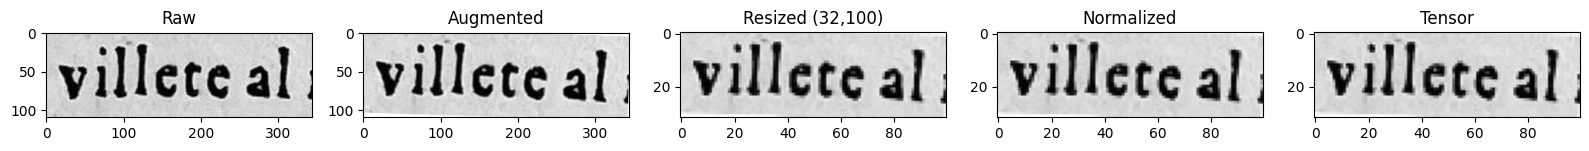

In [18]:
#Visualizing preprocessing that is to be applied before modelling:
img_path, label = train_data[1]

img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(16,4))
plt.subplot(1,5,1)
plt.imshow(img, cmap="gray")
plt.title("Raw")
print("Raw:", img.shape, img.dtype, img.min(), img.max())

#Applying the augmentation pipeline: NOTE: Agmentation does not resize image.
aug = train_transform(image=img)["image"]
plt.subplot(1,5,2)
plt.imshow(aug, cmap="gray")
plt.title("Augmented")
print("Aug:", aug.shape, aug.dtype, aug.min(), aug.max())

#Resizing image:
imgH = 32 #as CRNN models expect fixed image height of 32 pixels
h, w = aug.shape
new_w = int(imgH * w / h) #rescaling width wrt height while preserving aspect ratio
resized = cv2.resize(aug, (new_w, imgH))

plt.subplot(1,5,3)
plt.imshow(resized, cmap="gray")
plt.title(f"Resized (32,{new_w})")
print("Resize:", resized.shape, resized.dtype, resized.min(), resized.max())


#Normalizing pixel values between 0-1:
norm = resized.astype(np.float32) / 255.0 #NOTE- neural networks require float as input.
plt.subplot(1,5,4)
plt.imshow(norm, cmap="gray")
plt.title("Normalized")
print("Norm:", norm.shape, norm.dtype, norm.min(), norm.max())


#Converting image to tensor:
#Numpy array -> tensor (NN training in Pytorch req tensor inputs)
tensor_img = torch.from_numpy(norm).unsqueeze(0)
plt.subplot(1,5,5)
plt.imshow(tensor_img.squeeze().numpy(), cmap="gray")
plt.title("Tensor")
print("Tensor:", tensor_img.shape)

plt.tight_layout()
plt.show()

In [27]:
#Creating Dataset class:
class OCRDataset(Dataset):

    def __init__(self, data, transform=None, imgH=32):
        self.data = data
        self.transform = transform
        self.imgH = imgH

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        img_path, label = self.data[idx]

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise ValueError(f"Failed to read image: {img_path}")

        if self.transform:
            img = self.transform(image=img)["image"]
        
        imgH = 32
        h, w = img.shape
        new_w = int(imgH * w / h)
        
        img = cv2.resize(img, (new_w, imgH))

        img = img.astype(np.float32) / 255.0

        tensor_img = torch.from_numpy(img).unsqueeze(0)

        return tensor_img, label

In [49]:
#Creating Dataset object from train data:
train_ds = OCRDataset(train_data, transform=train_transform)

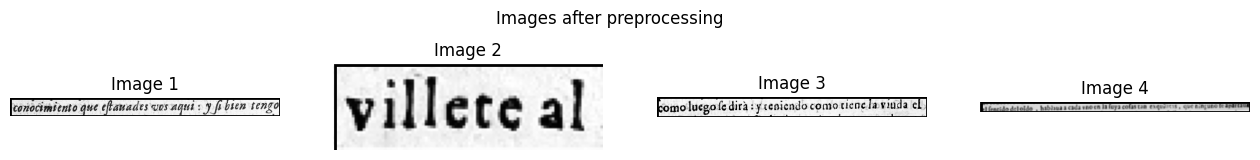

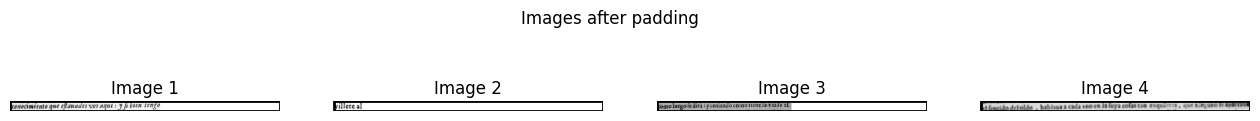

Original widths: [487, 100, 435, 873]
Batch padded width: 873


In [21]:
#Next, applying padding to a few images and visualizing: (Padding is required as all images in a Pytorch batch need to be of the same size)
num_samples = 4  # how many images to visualize

processed_images = []
labels = []

#Applying preprocessing pipeline to replicate actual preprocessing before padding:
for i in range(num_samples):
    img_path, label = train_data[i]
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    aug = train_transform(image=img)["image"]
    imgH = 32
    h, w = aug.shape
    new_w = int(imgH * w / h)
    resized = cv2.resize(aug, (new_w, imgH))
    norm = resized.astype(np.float32) / 255.0
    tensor_img = torch.from_numpy(norm).unsqueeze(0)

    processed_images.append(tensor_img)
    labels.append(label)


#Vizualizing preprocessed images for later comparison with padded images:
plt.figure(figsize=(16,2))
for i, img in enumerate(processed_images):
    ax = plt.subplot(1, num_samples, i+1)
    ax.imshow(img.squeeze().numpy(), cmap="gray")
    _, h, w = img.shape
    rect = patches.Rectangle(
        (0, 0), w, h,
        linewidth=2,
        edgecolor="black",
        facecolor="none")
    ax.add_patch(rect)
    plt.title(f"Image {i+1}")
    plt.axis("off")

plt.suptitle("Images after preprocessing")


#Applying padding:
widths = [img.shape[2] for img in processed_images] #list of all image widths for all images under consideration.
max_w = max(widths) #finding max image width

padded_images = []

for img in processed_images:
    c, h, w = img.shape
    padded = torch.ones((c, h, max_w)) #initializing empty white image- pixel value 1 is white as 255[white] has been already normalized to 1 in previous 
                                       #step
    padded[:, :, :w] = img #inserting image to left side of the blank image created
    padded_images.append(padded)


# Vizualizing padded images:
plt.figure(figsize=(16,2))
for i, img in enumerate(padded_images):
    ax = plt.subplot(1, num_samples, i+1)
    ax.imshow(img.squeeze().numpy(), cmap="gray")
    _, h, w = img.shape
    rect = patches.Rectangle(
        (0, 0), w, h,
        linewidth=2,
        edgecolor="black",
        facecolor="none")
    ax.add_patch(rect)
    plt.title(f"Image {i+1}")
    plt.axis("off")

plt.suptitle("Images after padding")
plt.show()


print("Original widths:", widths)
print("Batch padded width:", max_w)

In [30]:
#Writing function for padding:
def ocr_collate(batch):
    images, labels = zip(*batch)
    widths = [img.shape[2] for img in images]
    max_w = max(widths)
    padded_images = []
    for img in images:
        c, h, w = img.shape
        padded = torch.ones((c, h, max_w))
        padded[:, :, :w] = img
        padded_images.append(padded)
    images = torch.stack(padded_images) #converting padded images to a batch tensor
    return images, labels

In [50]:
#For loading data and dividing data into batches for training:
train_loader = DataLoader(
    train_ds,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    collate_fn=ocr_collate)

In [178]:
#Removing the module. prefix from the key names in the downloaded model parameters for compatibility with local model:
new_ckpt = {} #Dictionary for Storing Checkpoint values cleanly

for k, v in ckpt.items():
    new_key = k.replace("module.", "")
    new_ckpt[new_key] = v
    
#Next, loading the downloaded weights to the model architecture defined:
model.load_state_dict(new_ckpt, strict=False)

#The result shows that the downloaded model has extra keys related to the TPS layers but my model structure is not using them.

_IncompatibleKeys(missing_keys=[], unexpected_keys=['Transformation.LocalizationNetwork.conv.0.weight', 'Transformation.LocalizationNetwork.conv.1.weight', 'Transformation.LocalizationNetwork.conv.1.bias', 'Transformation.LocalizationNetwork.conv.1.running_mean', 'Transformation.LocalizationNetwork.conv.1.running_var', 'Transformation.LocalizationNetwork.conv.1.num_batches_tracked', 'Transformation.LocalizationNetwork.conv.4.weight', 'Transformation.LocalizationNetwork.conv.5.weight', 'Transformation.LocalizationNetwork.conv.5.bias', 'Transformation.LocalizationNetwork.conv.5.running_mean', 'Transformation.LocalizationNetwork.conv.5.running_var', 'Transformation.LocalizationNetwork.conv.5.num_batches_tracked', 'Transformation.LocalizationNetwork.conv.8.weight', 'Transformation.LocalizationNetwork.conv.9.weight', 'Transformation.LocalizationNetwork.conv.9.bias', 'Transformation.LocalizationNetwork.conv.9.running_mean', 'Transformation.LocalizationNetwork.conv.9.running_var', 'Transforma

In [112]:
#Printing out the weights corrosponding to the final prediction layer:
print(ckpt["module.Prediction.weight"])
print(ckpt["module.Prediction.bias"])

tensor([[-0.1551,  0.0523, -0.0088,  ..., -0.0074,  0.0192,  0.1050],
        [-0.6849,  0.0041, -0.0313,  ...,  0.0745, -0.0589,  0.1132],
        [-0.6352,  0.2659,  0.0186,  ..., -0.0424, -0.0151,  0.0443],
        ...,
        [-0.8234, -0.0581, -0.0670,  ...,  0.2254, -0.0645,  0.1287],
        [-0.4536,  0.1300,  0.0289,  ...,  0.0583,  0.0146,  0.2333],
        [-0.0908,  0.0457, -0.0886,  ..., -0.1506, -0.0219,  0.0957]])
tensor([ 0.1600, -1.9966, -1.6600, -2.1352, -2.0590, -2.3264, -2.3076, -2.3808,
        -2.2890, -2.4244, -2.1667, -0.2148, -0.8175, -0.6231, -0.5714, -0.1431,
        -0.8042, -0.7360, -0.4818, -0.2980, -1.6307, -1.1224, -0.4259, -0.6506,
        -0.2007, -0.3668, -0.7199, -1.8443, -0.2554, -0.2692, -0.1863, -0.5117,
        -0.9768, -0.8258, -1.4844, -0.8802, -1.7038])


In [113]:
#Printing the shape of the weights and bias in the final prediction layer:
print(ckpt["module.Prediction.weight"].shape)
print(ckpt["module.Prediction.bias"].shape)

torch.Size([37, 256])
torch.Size([37])


In [22]:
#Thus, the model predicts 37 characters,and the previous layer has 256 hidden units.
#Replacing the final prediction layer as I want to predict the characters in the character set of the Printed Spanish text.

#Computing no of characters in my character set:
num_classes = len(charset) + 1

print(num_classes)

79


In [23]:
#Replacing the final model layer:
import torch.nn as nn
model.Prediction = nn.Linear(
    model.Prediction.in_features, #Prediction.in_features=512 (size of input to prediction layer)
    num_classes # =79(size of output from prediction layer)
)
#The last layers weights will be randomly initialized

In [24]:
print(model) #As we can see, the output dimension of the prediction layer has been updated to 79 (for my character set)

Model(
  (FeatureExtraction): ResNet_FeatureExtractor(
    (ConvNet): ResNet(
      (conv0_1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn0_1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv0_2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn0_2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=Tru

In [181]:
#Defining CTC loss function for model training:
criterion = nn.CTCLoss(blank=0, 
                       zero_infinity=True) # For numerical stability-To prevent loss from going to infinity if there is mismatch b/w length of label 
                                           # and prediction- i.e, model output length < target sequence length

In [36]:
#Building character encoder:
#Character encoder maps each character in character set to an index- the NN will learn to predict the sequence of indices corrosponding to the label 
#characters:
char_to_idx = {c: i+1 for i, c in enumerate(charset)}
idx_to_char = {i+1: c for i, c in enumerate(charset)}

In [183]:
#encoding function for labels- so that CTC loss can be applied:
def encode_labels(labels, char_to_idx):
    encoded = []
    lengths = []
    for label in labels:
        seq = [char_to_idx[c] for c in label if c in char_to_idx]
        encoded.extend(seq)
        lengths.append(len(seq)) #eg format- let labels=["cat", "dog", "hi"]
                                # and after char_to_idx let seq no1=[3,1,20], seq no2=[4,15,7], seq no3=[8,9]
                                #Then targets = [3,1,20,4,15,7,8,9] and lengths = [3,3,2] 
    return torch.LongTensor(encoded), torch.LongTensor(lengths) #list to tensor

In [204]:
#Applying model to one batch of training data to catch any Dimensionality issues:

#Getting batch of (images, labels) from train_loader:
images, labels = next(iter(train_loader))

In [208]:
#Printing shape of batch of 16 images and labels:
print(images.shape)
print(labels)

torch.Size([16, 1, 32, 533])
('de Matias; y plega a Dios, que una vez u otra no de-', 'pel.', 'ventud; pero a esta, como recuer-', '8 Al fin de este testimonio, dize, que los Con-', 'esto al las cuatro,', 'siqui sunt, crudite Villalpan. adl. 22. tit. I. p. 7. patt. 2.', 'muerte de su marido, que es la inspreccion que hizo el derecho, aun en terminos de concurso de acusadores,', 'num. 153.', 'biera despuesto dos veces en tanto peligro, como es ve-', 'gastado a su padre, y por ser menor de veinte y cin', 'dotium, & quae post antiquos tradit Menoch. de arbitra-', 'primer lugar en acusar, le tiene priuative en perdonar,', 'Padilla inI. transigere, nu. 57. C. de transact. his verbis:', 'educacion de vuestra Compañia,', 'pretensiones que tiene; y declara, que con estas ca', 'Iacinto Gomez Pi-')


In [209]:
#Passing one batch of images through CRNN model:

preds = model(images,None) #images= batch of images from data loader
#images is a tensor with shape: [batch_size, channels, height, width]
#Shape of output:(preds.shape) = [batch_size, sequence_length, num_classes]
#Preds is made of raw probailities: preds[i,j,k]- for ith image, on predicting jth chracter of seq, probability that the character is kth one in the char
#set

preds.shape

torch.Size([16, 134, 79])

In [120]:
preds = preds.log_softmax(2) #Becomes matrix of Log probabilities of characters. 
preds = preds.permute(1, 0, 2) #Rearrange to [seq_len, batch_size, num_classes] to match CTC input format.

batch_size = preds.size(1) #Here, 16.
seq_len = preds.size(0) #Lenth of sequence the model predicts for each image

preds_size = torch.IntTensor([seq_len] * batch_size) 

encoded, lengths = encode_labels(labels, char_to_idx) #Encoding labels according to index gives encodings and lengths of words
loss = criterion(preds, encoded, preds_size, lengths)

In [184]:
#Setting up optimizer:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), #For Phase 1 of training, filtering for the parameters that required updating
                                                           #- p.requires_grad=True.This excludes parameters of the CNN which have been frozen
    lr=0.001)

In [31]:
#Preparing validation dataset and data loader:
val_ds = OCRDataset(val_data, transform=None) #Transformation pipeline is not needed here- we want to validate on true values only.
val_loader = DataLoader(
    val_ds,
    batch_size=16,
    shuffle=False,   # no shuffling during validation
    num_workers=0,
    collate_fn=ocr_collate #the padding function used for train data as well.
)

In [34]:
#function to decode prediction-> text: I am using Greedy Decoding:

def greedy_decode(preds, idx_to_char, blank=0):
    
    # preds shape: [batch size, sequence length, number of character classes]
    preds = preds.detach().cpu() #Detach- removes tensor from gradient computation graph #GPU to CPU- not applicable here

    pred_indices = preds.argmax(2)   #Calculating which character(index) out of all character classes has the max probability.
    #Pred_indices.shape=[batch size, sequence length]- matrix of predicted character index
    
    decoded_batch = [] #To store decoded strings

    for seq in pred_indices: #looping through 16(batch size) predicted image sequences:
        prev = None #to remove duplicates       
        decoded = "" #to hold the decoded image prediction

        for idx in seq: #looping through the predicted image sequence of a single image:
            idx = idx.item() #Converting tensor to integer.
            if idx != blank and idx != prev: #if not blank and if not repetition:
                decoded += idx_to_char[idx]
            prev = idx
        decoded_batch.append(decoded)
    return decoded_batch

In [210]:
#Decoding the preds for this current batch:
decoded_preds = greedy_decode(preds, idx_to_char)

In [211]:
decoded_preds 
# On re-running with the final predicted model (that I have fitted in the later steps), we can see that the greedy decoded prediction of the batch
#matches the ground truth labels of this batch to a great extent.

['de Matias: y plega a Dios, que una vez, uetra m den',
 'pel.',
 'ventud; pero a esta, como recuer-',
 ' Al fin de este testimonio, dize, que los Con',
 'esto a las cuatro,',
 'siqui sunt, erudite Villalpan ad. 22. tit. I. p. 7. part. 2.',
 'muerte dosu marido, quedes la inspeccion que hizo e',
 'num. 153.',
 'vierades puesto dos veces en tanto peligro, como es ve-',
 'gastado a su padre, y por ser menor de veinte y cin',
 'dotiu, &e quae post antiquos tradi: Menoch. de arbitra-',
 'primer lugar en acusar, le tiene priuative en perdonar,.',
 'Padilla inI. transigere, nu.57. C. de transact. his verbiss',
 'educacion de vuestra Compañia,',
 'pretensiones que tiene,: y declara, que conestas ca',
 'acinto Gomez Pi-']

### Step 7.2- Defining Model Evaluation Metrics::

### Model Evaluation Metrics- CER and WER:

### Character Error Rate (CER):

Measures how many characters in the predicted text are wrong compared to the ground truth.
It is calculated using **Levenshtein distance**, which counts the minimum number of changes needed to convert one string into another.
The allowed edits are:
1. Insertion (I) – adding an extra character
2. Deletion (D) – missing a character
3. Substitution (S) – replacing one character with another
   
Formula:
$$
CER = \frac{S + D + I}{N}
$$
Where:

- S = Number of substitutions  
- D = Number of deletions  
- I = Number of insertions  
- N = Number of characters in the ground truth


Example use: Ground truth="cat", Prediction="mat", then to go from GT to Prediction, we need 1 substitution- "m" to "c".
N = 3 (length of GT)

Then, CER = 0.33333
    

### Word Error Rate (WER):

Measures how many words in the predicted text are wrong compared to the ground truth. Uses the same formuala as CER, just words are the units of measurement as opposed to individual characters.

Example use: Ground truth="cat is sleepy", Prediction="cat is slepy", then to go from GT to Prediction, we need 1 substitution- "slepy" to "sleepy".
N=3 (length of GT)

Then, WER = 0.33333

### Why are we evaluating model using CER/WER and not the CTC loss value?
The model is trained by minimizing the CTC loss-i.e, the parameters are updated using this loss in the training process. A lower CTC loss also means that the model assigns higher probability to the correct sequence.

However, this probability is calculated before decoding and includes many possible alignments.CTC uses probabilities of all valid alignments, not just the final decoded text. The final output also depends on the decoding method used, not only the predicted alignments.

CER takes into account only the final decoded text- thus evaluating performance of the model+decoder.This metric is important because, in OCR systems, what ultimately matters is the accuracy of the final decoded prediction.

Thus, in the model training, at each step, the model which gives lowest CER on the Validation dataset(and not the model with the lowest Validation loss) is picked up up for the subsequent steps.

In [44]:
#Defining Levenshtein distance function for CER calculation:
def levenshtein(a, b): #Inputs-(Predicted text, GT text)
    m = len(a)
    n = len(b)
    dp = [[0]*(n+1) for _ in range(m+1)] #creating 2D matrix of zeroes of dimensions ((m+1), (n+1))
    #dp[i][j] = minimum edit distance between a[:i] and b[:j] or how many edits are needed to convert first i characters of a into
    #first j characters of b

    #[0,0] position corrosponds to blanks.
    
    #Filling first column and row:
    for i in range(m+1):
        dp[i][0] = i  #no of deletions needed to convert the first i characters of a into an empty string.
    for j in range(n+1):
        dp[0][j] = j  #no of insertions neede to convert an empty string into the first j characters of b.
        
    for i in range(1, m+1):
        for j in range(1, n+1):
            cost = 0 if a[i-1] == b[j-1] else 1
            dp[i][j] = min(
                dp[i-1][j] + 1,      # deletion
                dp[i][j-1] + 1,      # insertion
                dp[i-1][j-1] + cost  # substitution
            )
    return dp[m][n] #Result= Bottom-right of matrix

In [43]:
#Defining Character Error Rate calculation function for a batch:
def calculate_cer(pred_texts, gt_texts):
    total_dist = 0 #to store total edit distance for batch
    total_chars = 0 # to store total number of characters in all ground truth text.
    for pred, gt in zip(pred_texts, gt_texts):
        dist = levenshtein(pred, gt)
        total_dist += dist
        total_chars += len(gt)
    if total_chars == 0:
        return 0
    return total_dist / total_chars

In [84]:
#Function to calculate Word Error Rate:- Same logic as CER- applied to words in place of characters:
def calculate_wer(pred_texts, gt_texts):
    total_dist = 0
    total_words = 0
    for pred, gt in zip(pred_texts, gt_texts):
        pred_words = pred.split()
        gt_words = gt.split()
        dist = levenshtein(pred_words, gt_words)
        total_dist += dist
        total_words += len(gt_words)
    if total_words == 0:
        return 0
    return total_dist / total_words

In [194]:
#Stage 1 Model Training:(Training with CNN frozen, for 10 Epochs)
num_epochs = 10 

#initiating variables to store the lowest total loss/CER accross all epochs:
best_train_loss = float("inf")
best_val_loss = float("inf")
best_cer = float("inf")

for epoch in range(num_epochs):
    
    #Training Phase:
    model.train()
    total_loss = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        preds = model(images, None)  #Passing a batch of images to model
        log_preds = preds.log_softmax(2) #Character probabilities calculated
        ctc_preds = log_preds.permute(1,0,2)  #Permutation for compatibility with expected structure of CTC loss calculation
        seq_len = ctc_preds.size(0)
        batch_size = ctc_preds.size(1)
        preds_size = torch.IntTensor([seq_len] * batch_size)
        encoded, lengths = encode_labels(labels, char_to_idx) #Converting ground truth labels to encoded indexes for CTC calculation
        loss = criterion(ctc_preds, encoded, preds_size, lengths) 

        #Updating model parameters:
        optimizer.zero_grad() #clearing previously stored gradients from optimizer i.e, gradients = 0        
        loss.backward() #Carries out backpropagation i.e, calculates gradients- del(Loss)/del(Parameter) for all unfrozen model parameters        
        optimizer.step() #Updating parameters using calculated gradients-new_para = old_para − learning_rate × gradient
        total_loss += loss.item() #Total loss for current epoch

    train_loss = total_loss / len(train_loader) #Average training loss per batch for current epoch

    #Validation phase:
    model.eval()
    val_loss = 0 #Variable to store total validation loss in current epoch
    all_preds = [] #list to store all predicted texts
    all_labels = [] #list to store all ground truth labels

    with torch.no_grad(): #Gradients not computed
        for images, labels in tqdm(val_loader, desc="Validation"):
            
            #Same as training loop:
            
            preds = model(images, None)
            log_preds = preds.log_softmax(2)
            ctc_preds = log_preds.permute(1,0,2)
            seq_len = ctc_preds.size(0)
            batch_size = ctc_preds.size(1)
            preds_size = torch.IntTensor([seq_len] * batch_size)
            encoded, lengths = encode_labels(labels, char_to_idx)
            loss = criterion(ctc_preds, encoded, preds_size, lengths)
            val_loss += loss.item()

            #For validation data, we want to calculate CER:
            decoded_preds = greedy_decode(preds, idx_to_char) #Greedy decoding predicted values
            all_preds.extend(decoded_preds) #Saving predicted values
            all_labels.extend(labels)

    val_loss = val_loss / len(val_loader) #Average validation loss per batch in current epoch.

    cer = calculate_cer(all_preds, all_labels) #Calculating Validation CER for epoch

    #Saving best models for later use:
    if train_loss < best_train_loss:
        best_train_loss = train_loss
        torch.save(model.state_dict(), "greedy_best_train_loss_model.pth")
        print("Saved best TRAIN loss model (greedy)")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "greedy_best_val_loss_model.pth")
        print("Saved best VALIDATION loss model (greedy)")

    if cer < best_cer:
        best_cer = cer
        torch.save(model.state_dict(), "greedy_best_cer_model.pth")
        print("Saved best CER model (greedy)")

    # Printing out Loss and CER values for each Epoch:
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"CER        : {cer:.4f}")

    #Printing out few predictions every epoch from Validation Set (Sanity Check):
    print("\nSample Predictions:\n")
    pairs = list(zip(all_preds, all_labels))
    sample_pairs = random.sample(pairs,min(5, len(pairs)))
    for pred, gt in sample_pairs:
        print("GT   :", gt)
        print("Pred :", pred)
        print()



alidation: 100%|████████████████████████████████████████████████████████████████████████| 3/3 [00:11<00:00,  3.85s/it]

Saved best TRAIN loss model (greedy)
Saved best VALIDATION loss model (greedy)
Saved best CER model (greedy)

Epoch 1/10
Train Loss : 10.2423
Val Loss   : 3.0649
CER        : 0.9397

Sample Predictions:

GT   : la adultera tan convencida de su delito, que más se pue-
Pred : a dd da 

GT   : cabeça de la familia ofendida, tenia la voz en su nom-
Pred :     

GT   : bos una misma carne y sangre, no ay persona mas con-
Pred :      

GT   : dor, inocencia, y christiana hu-
Pred :  

GT   : Vunque es regular en estos delitos venéreos la
Pred : 





alidation: 100%|████████████████████████████████████████████████████████████████████████| 3/3 [00:12<00:00,  4.03s/it]

Saved best TRAIN loss model (greedy)
Saved best VALIDATION loss model (greedy)
Saved best CER model (greedy)

Epoch 2/10
Train Loss : 2.4688
Val Loss   : 1.5811
CER        : 0.3917

Sample Predictions:

GT   : Arzobispo de Milán Subdelegado del Consejo, en que
Pred : arobipo deilansubdeleadodelconleioen qu

GT   : mayor, y Canonigo de la santa Catedral Iglesia
Pred : m yor ycanoniodelaana catedrall lesa

GT   : cabeça de la familia ofendida, tenia la voz en su nom-
Pred : caoeadelasamiliaosndidas teniaslaoennom

GT   : que de él dio doña Leonor Rauasco, por dezirla
Pred : quedeldiodoaoauapordiia

GT   : dor, inocencia, y christiana hu-
Pred : or,yinoeencia y ehritianau





alidation: 100%|████████████████████████████████████████████████████████████████████████| 3/3 [00:12<00:00,  4.04s/it]

...

Saved best TRAIN loss model (greedy)
Saved best VALIDATION loss model (greedy)
Saved best CER model (greedy)

Epoch 8/10
Train Loss : 0.6984
Val Loss   : 0.6321
CER        : 0.1752

Sample Predictions:

GT   : diola monje professo de
Pred : diola monje professo de

GT   : de los libros dispone, fue acordado que
Pred : sio delos libros dispone, sue a cordado que

GT   : nras Audiencias Alcaldes, alguaziles de la
Pred : nras Audiencias Alcaldes alguaziles de la

GT   : mas si consideraseis mis trabajos, no habalriades así,
Pred : mus f carside nastis mis trabajos, nohablariades 

GT   : la brevedad, y claridad de este papel, lo
Pred : labrevedad y claridad deste papel lo





alidation: 100%|████████████████████████████████████████████████████████████████████████| 3/3 [00:11<00:00,  3.99s/it]

Saved best TRAIN loss model (greedy)
Saved best VALIDATION loss model (greedy)
Saved best CER model (greedy)

Epoch 9/10
Train Loss : 0.6620
Val Loss   : 0.5956
CER        : 0.1673

Sample Predictions:

GT   : dado bien a entender el ingenio, y erudicion de v. m. y esta obra de las Etymologias ha de dar no-
Pred : dado bien a enrenderesl ingeno, y erudicion de vn y esta obrade las eryinologias hade dar ro

GT   : tassado por los del nuestro Consejo, y es-
Pred : tassado por los del nuestro Cosejo, y es

GT   : del Numero desta villa, entre Iacinto Gomez Pi-
Pred : del Numero desta villa,entre dacinto Gomez Pi-

GT   : Arzobispo de Milán Subdelegado del Consejo, en que
Pred : Arcobispo de MilanSubdelegado del Consejo, en que

GT   : castidad, aver quebrantado su casa, siendo de muy luci-
Pred : castidad auer quebranradosucasa sendo de muy luci





alidation: 100%|████████████████████████████████████████████████████████████████████████| 3/3 [00:12<00:00,  4.00s/it]

Saved best TRAIN loss model (greedy)
Saved best VALIDATION loss model (greedy)
Saved best CER model (greedy)

Epoch 10/10
Train Loss : 0.6095
Val Loss   : 0.5555
CER        : 0.1604

Sample Predictions:

GT   : d leg. IuI. de adult. haec Padilla, Sua-
Pred : a leg lul de adult hxe Padilla,Sua-

GT   : castidad, aver quebrantado su casa, siendo de muy luci-
Pred : castida d auer quebranrado su easa sendo de muy luei

GT   : que de él dio doña Leonor Rauasco, por dezirla
Pred : que de el dio do i a seoo Rauase, por dizirla

GT   : dor, inocencia, y christiana hu-
Pred : 2 e or, inocencia, y christiana hu-

GT   : Arzobispo de Milán Subdelegado del Consejo, en que
Pred : Arcobispo de Milan Sub delegado del Consejo, en que



### Stage 1 Training (CNN Weights Frozen)- Final Training Results:

The model was trained for 10 Epochs and the **Character Error Rate** decreased from 93% in Epoch 1 to **16% in Epoch 10**.

Thus, after training, about 16% of characters in the predicted text differ from the ground truth.
The Character Error Rate (CER) decreased sharply during the initial epochs, followed by a gradual plateau, reaching approximately 16% after 10 epochs.

In [195]:
#Loading best model:
model.load_state_dict(torch.load("greedy_best_cer_model.pth"))

<All keys matched successfully>

### Step 7.3- Model Training Stage 2 (Training Full Model):
Unfreezing the CNN layers and training the complete model with a lower learning rate:

In [196]:
#Unfreezing the CNN to train whole model:
for param in model.FeatureExtraction.parameters():
    param.requires_grad = True

In [197]:
#Reducing the learning rate to prevent overwriting useful weights:
optimizer = torch.optim.Adam([
    {"params": model.FeatureExtraction.parameters(), "lr": 1e-5},
    {"params": model.SequenceModeling.parameters(), "lr": 1e-4},
    {"params": model.Prediction.parameters(), "lr": 1e-4}
])

In [198]:
#Stage 2 Model Training:20 Epochs
#Same loop as before

num_epochs = 20

best_train_loss = float("inf")
best_val_loss = float("inf")
best_cer = float("inf")

for epoch in range(num_epochs):
    #Training:
    model.train()
    total_loss = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):

        preds = model(images, None) 
        log_preds = preds.log_softmax(2)
        ctc_preds = log_preds.permute(1,0,2) 
        seq_len = ctc_preds.size(0)
        batch_size = ctc_preds.size(1)
        preds_size = torch.IntTensor([seq_len] * batch_size)
        encoded, lengths = encode_labels(labels, char_to_idx)
        loss = criterion(ctc_preds, encoded, preds_size, lengths)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    train_loss = total_loss / len(train_loader)

    #Validation:
    model.eval()

    val_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation"):
            preds = model(images, None)
            log_preds = preds.log_softmax(2)
            ctc_preds = log_preds.permute(1,0,2)
            seq_len = ctc_preds.size(0)
            batch_size = ctc_preds.size(1)
            preds_size = torch.IntTensor([seq_len] * batch_size)
            encoded, lengths = encode_labels(labels, char_to_idx)
            loss = criterion(ctc_preds, encoded, preds_size, lengths)
            val_loss += loss.item()

            decoded_preds = greedy_decode(preds, idx_to_char)

            all_preds.extend(decoded_preds)
            all_labels.extend(labels)

    val_loss = val_loss / len(val_loader)

    cer = calculate_cer(all_preds, all_labels)

    if train_loss < best_train_loss:
        best_train_loss = train_loss
        torch.save(model.state_dict(), "stage2_best_train_loss_model.pth")
        print("Saved best TRAIN loss model (stage2)")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "stage2_best_val_loss_model.pth")
        print("Saved best VALIDATION loss model (stage2)")

    if cer < best_cer:
        best_cer = cer
        torch.save(model.state_dict(), "stage2_best_cer_model.pth")
        print("Saved best CER model (stage2)")

    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"CER        : {cer:.4f}")


    print("\nSample Predictions:\n")
    pairs = list(zip(all_preds, all_labels))
    sample_pairs = random.sample(pairs,min(5, len(pairs)))

    for pred, gt in sample_pairs:
        print("GT   :", gt)
        print("Pred :", pred)
        print()



alidation: 100%|████████████████████████████████████████████████████████████████████████| 3/3 [00:11<00:00,  3.99s/it]

Saved best TRAIN loss model (stage2)
Saved best VALIDATION loss model (stage2)
Saved best CER model (stage2)

Epoch 1/20
Train Loss : 0.5037
Val Loss   : 0.5240
CER        : 0.1398

Sample Predictions:

GT   : Prendas son estas señor, para que yo estime tal deudo, quando v. m. por su persona no me diera
Pred : prendas son estas señor, para que yo estime tal deudo, quindo v m por su persona no me diera

GT   : tuviera algun derecho de acusar esta ileso y entero, y no remitido, I. t. & L. item his, ff. ex quibus caus. maior.
Pred : coiena lgun de echo de ay eres quildo y emietro, y

GT   : cabeça de la familia ofendida, tenia la voz en su nom-
Pred : caboca de lafamilia ofendida, tenia la vozen su nom.

GT   : pil. heredit. & matrimonium durare dicitur vno eorum
Pred : pileacredin ee marrimonium duraredicitur uno corun

GT   : conclusa la causa
Pred : conclusa la causa





alidation: 100%|████████████████████████████████████████████████████████████████████████| 3/3 [00:12<00:00,  4.10s/it]

Saved best TRAIN loss model (stage2)
Saved best VALIDATION loss model (stage2)
Saved best CER model (stage2)

Epoch 2/20
Train Loss : 0.4424
Val Loss   : 0.4786
CER        : 0.1382

Sample Predictions:

GT   : d leg. IuI. de adult. haec Padilla, Sua-
Pred : a leg lul de adult hx e Padilla,Sua-

GT   : la adultera tan convencida de su delito, que más se pue-
Pred : la adultera tan convencida de su delito, que as fe pue-

GT   : bos una misma carne y sangre, no ay persona mas con-
Pred : bos umamisma carne y sangre, no ay persona mas con.

GT   : que de él dio doña Leonor Rauasco, por dezirla
Pred : que de el dio do i a 1eono Rauasco, por dizir la

GT   : Vunque es regular en estos delitos venéreos la
Pred : Vnque es regular en estos delitos venereos la





alidation: 100%|████████████████████████████████████████████████████████████████████████| 3/3 [00:10<00:00,  3.66s/it]

...

Saved best CER model (stage2)

Epoch 18/20
Train Loss : 0.2374
Val Loss   : 0.3574
CER        : 0.0963

Sample Predictions:

GT   : des) tienen abreviado el mas se-
Pred : des ) tienen abreviado el mas se-

GT   : mayor, y Canonigo de la santa Catedral Iglesia
Pred : mayor, y Canonigo de la Santa Catedral lglesia

GT   : que de él dio doña Leonor Rauasco, por dezirla
Pred : que de el dio do ;a Leono. Rauasco, por dezir la

GT   : del Numero desta villa, entre Iacinto Gomez Pi-
Pred : del Numero desta villa, entre lacinto Gomez Pi-

GT   : castidad, aver quebrantado su casa, siendo de muy luci-
Pred : castidad aver quebrantado su casa sendo de muy luci-





alidation: 100%|████████████████████████████████████████████████████████████████████████| 3/3 [00:11<00:00,  3.96s/it]

Saved best TRAIN loss model (stage2)

Epoch 19/20
Train Loss : 0.2271
Val Loss   : 0.3554
CER        : 0.1016

Sample Predictions:

GT   : de los libros dispone, fue acordado que
Pred : sio de los libros dispone, fue a cordado que

GT   : cion, y Capellan de su Magestad, y no he allado en el cosa contraria a
Pred : cion, y Capelan de su Magestad, y no he hallado en el cosa contraria a

GT   : ciste ayer por la mañana, como también por dar cobro
Pred : iste ay en per la manana, como tambien por dar cobro

GT   : de Milán.
Pred : de Milan

GT   : bos una misma carne y sangre, no ay persona mas con-
Pred : bos unal misma carne y sangre, no ay persona mas con-





alidation: 100%|████████████████████████████████████████████████████████████████████████| 3/3 [00:11<00:00,  3.95s/it]

Saved best VALIDATION loss model (stage2)

Epoch 20/20
Train Loss : 0.2306
Val Loss   : 0.3471
CER        : 0.0995

Sample Predictions:

GT   : hijo todo lo que montaua su legitima materna,
Pred : hijo todo loque montava su legitima materna

GT   : cabeça de la familia ofendida, tenia la voz en su nom-
Pred : cabeca de la familia ofendida, tenia la voz en su nom

GT   : salen no ha mudado de condicion
Pred : salen no ha mudado de condicion

GT   : partidas, que refiere por menor, por cuenta de lo
Pred : partidas, que refiere pormenor, por cuenta de lo

GT   : les dais enten-
Pred : les dais enten-



### Full Model Training- Final Results:

The model was trained for 20 Epochs and the best **Character Error Rate** achieved on Validation Data was **9.63% in Epoch 18**.

**Thus, the model predicted about 90.4% characters from the Validation dataset correctly and 9.6% of characters incorrectly.**

In [215]:
#Loading best model:
model.load_state_dict(torch.load("stage2_best_cer_model.pth"))

<All keys matched successfully>

In [201]:
#Downloading best model for later use:
FileLink("stage2_best_cer_model.pth") #Download link for only model parameters

C:\Users\91861\stage2_best_cer_model.pth

In [202]:
#Saving additionmal necessary information:
torch.save({
    "model_state_dict": model.state_dict(),
    "char_to_idx": char_to_idx,
    "idx_to_char": idx_to_char
}, "stage2_best_cer_model_complete1.pth")

#Downoad link for full model:
FileLink("stage2_best_cer_model_complete1.pth")


C:\Users\91861\stage2_best_cer_model_complete1.pth

In [25]:
#On kernel dying, code to use saved parameters:
#model = Model(opt)     # load same architecture as training- this line, then replce last layer
model.load_state_dict(torch.load(r"C:\Users\91861\Downloads\stage2_best_cer_model.pth"))

<All keys matched successfully>

## Stage 3-Output refining using LLM Integration:

### Step 8- Integrating a Large Language Model:
**The Goal:** Use a trained large language model to refine the predictions of the CRNN model.

**Additional idea:** Provide a few pairs of ground truth labels and OCR predictions from the train dataset to an LLM. Prompt the LLM to analyze the patterns and differrences between the predictions and the ground truth and remember this information .Next, add the OCR predictions, one line at a time, to the prompt and ask the LLM Model to predict the ground truth from this predicted OCR output. Try some differrent prompting patterns and select the one with the lowest CER as the final prompt.Evaluate this best prompt on the test data to get the final accuracy score.

This is method is known as **'Few Shot Prompt Tuning'**.

To integrate an LLM-based post-processing step into the OCR pipeline, local language models were deployed using the Ollama framework. Relying on cloud APIs such as Google Gemini can introduce rate limits and usage restrictions, which may hinder large-scale batch processing of OCR outputs. To avoid these constraints and ensure uninterrupted processing, Ollama was used to run open-weight language models directly on local hardware, enabling efficient and unrestricted local inference.

Models Used- 
1. Mistral 7B
2. Qwen 2.5 7B

In [52]:
#Randomly sampling (OCR Predictions,Ground truth label) from training data to input to LLM for learning:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(train_loader, desc="Running OCR on train data"):
        #images = images.to(device)
        preds = model(images, None)
        decoded_preds = greedy_decode(preds, idx_to_char)
        all_preds.extend(decoded_preds)
        all_labels.extend(labels)

# Pairing predictions with GT labels:
pairs = list(zip(all_preds, all_labels))

# Taking a sample of 20 random examples:
sample_pairs = random.sample(pairs, min(20, len(pairs)))


unning OCR on train data: 100%|███████████████████████████████████████████████████████| 47/47 [03:27<00:00,  4.41s/it]

First, the Mistral-7B model is used due to its strong performance relative to its size and its reputation for efficient inference. As a lightweight yet capable model, it provides a practical starting point for experimentation with LLM-based OCR correction while maintaining manageable computational requirements.

**Passing OCR Predictions to LLM 'Mistral-7B'**- Using a simple prompt (without examples) to set a baseline.


In [63]:
def llm_refine_line(line):
    prompt = f"""The given line was extracted from a 16th century Spanish manuscript using OCR.
Your goal is to correct OCR errors and return a corrected line.

Rules:
- Correct spelling mistakes. While doing so, preserve historical spelling.
- Do NOT modernize language.
- Do NOT explain anything- JUST MAKE THE CHANGES.DONOT EXPLAIN ANYTHING ABOUT THE CHANGES- NO SIDE NOTES EXPLAINING HISTORICAL LANGUAGE STRUCTURE OR LOGIC
- Do NOT add notes like the following- Explanation: I've only made spelling corrections, preserving the original historical spelling and not modernizing language. The changes made are: 'ú' for 'u', 'ó' for 'o', and no changes to 'mo-' as it is already correctly spelled.
- Do NOT add notes like-"no changes made"
- Do NOT add notes like-(preserving the number as it is, but adding the correct punctuation)
-  Do NOT add notes like-(assuming "pitan" was meant to say "pito", which means "whistle")
- Do NOT add words.
- Return ONLY the corrected line.
- If there is a number, Do NOT change it.
- Do NOT add accents if the input line does not have it.
- Do NOT capitalize a letter if the input line letter is not capitalized and vice versa.
- Do NOT make changes like- replacing v with 'uno'


The line which is to be corrected: {line}

Corrected:
"""
    response = ollama.chat(
        model="mistral",
        messages=[{
            "role": "user",
            "content": prompt}])

    output = response['message']['content'].strip()

    # Sometimes models add prefixes like "Corrected:" Thus,removing the string:
    output = output.replace("Corrected:", "").strip()

    return output

In [53]:
#Getting first 100 training data points to input to LLM:
all_preds=all_preds[:100]
all_labels=all_labels[:100]

In [64]:
corrected_preds = [] #list to store LLM results.

for line in all_preds:
    corrected = llm_refine_line(line)
    corrected_preds.append(corrected)

In [65]:
print("\nExample LLM corrections:\n")

for i in range(10):
    print("OCR :", all_preds[i])
    print("LLM :", corrected_preds[i])
    print("GT  :", all_labels[i])
    print()


Example LLM corrections:

OCR : y primero el dicho libro este corregido y
LLM : y primero el dicho libro este correjido y
GT  : y primero el dicho libro este corregido y

OCR : sieio de la anes ma moneae eomo elcuehisto, y las tiver ano del lales enan lo, pira cnr earor ero n
LLM : seigio de la anses monesae oelo elcuehisto, y las tiver ano del lalces enan lo, pirra conear oro n
GT  : oficio de la mesma manera: como el cuchillo; y las tixeras, se hizieron ambos para cortar, pero no

OCR : sino también de assis- 46
LLM : sino también de asís- 46
GT  : sino también de assis- 46

OCR : co años jura la relacion de esta escritura, y estar, y
LLM : có annos jura la relación de esta escritura, y estaré, y
GT  : co años jura la relacion de esta escritura, y estar, y

OCR : ian por milagro en ellas, por el grande conocimiento, y nunca visto en hombre Español de la
LLM : Yan por milagro en ellas, por el gran conocimiento, y nunca visto en homem Español de la
GT  : nian por milagro en ellas, por

In [66]:
#Calculating the CER and WER values after passing OCR output through LLM

cer_before = calculate_cer(all_preds, all_labels)
cer_after = calculate_cer(corrected_preds, all_labels)

wer_before = calculate_wer(all_preds, all_labels)
wer_after = calculate_wer(corrected_preds, all_labels)

print("CER before LLM:", cer_before)
print("CER after LLM :", cer_after)

print("WER before LLM:", wer_before)
print("WER after LLM :", wer_after)

CER before LLM: 0.09545913218970736
CER after LLM : 0.19455095862764885
WER before LLM: 0.28632938643702904
WER after LLM : 0.4133476856835307


Currently, out of all the iterations with differrent prompts using **Mistral 7B** (all with no examples provided), the best iteration achieved 19% CER error rate which is much higher than the error rate of the simple CRNN model which is 9.5% on training data. It appears that the model is generating text in some cases instead of only editing, when required, according to rules. Next, we use Model Qwen 2.5 7B.

**Passing OCR Predictions to LLM Model Qwen 2.5 7B**- Using a simple prompt (without examples) to set a baseline.
This model was selected for experimentation as it provides a strong balance between performance and computational efficiency.It also offers improved instruction-following capability compared to several other models of similar size.


In [101]:
def refine_line(line, sample_pairs):

    prompt = f"""The given line was extracted from a 16th century Spanish manuscript using OCR.
Your goal is to correct OCR errors and return a corrected line.

Rules:
- Correct spelling mistakes. While doing so, preserve historical spelling.
- Do NOT modernize language.
- Do NOT explain anything- JUST MAKE THE CHANGES.DONOT EXPLAIN ANYTHING ABOUT THE CHANGES- NO SIDE NOTES EXPLAINING HISTORICAL LANGUAGE STRUCTURE OR LOGIC
- Do NOT add notes like the following- Explanation: I've only made spelling corrections, preserving the original historical spelling and not modernizing language. The changes made are: 'ú' for 'u', 'ó' for 'o', and no changes to 'mo-' as it is already correctly spelled.
- Do NOT add notes like-"no changes made"
- Do NOT add notes like-"preserving the number as it is, but adding the correct punctuation"
-  Do NOT add notes like-"assuming "pitan" was meant to say "pito", which means "whistle""
- Do NOT add words.
- Return ONLY the corrected line.
- If there is a number, Do NOT remove it.
- Do NOT add accents if the input line does not have it.
- Do NOT capitalize a letter if the input line letter is not capitalized and vice versa.
- Do NOT make changes like- replacing v with 'uno'
- VERY IMPORTANT- If a word is incomplete followed by a "-" sign, do NOT complete the word, KEEP WORD AS IT IS.


The line which is to be corrected: {line}
Return EXACTLY one line of text.
No explanation.
No extra characters.
THIS IS A TEXT EDITING TASK(ONLY WHEN REQUIRED) AND NOT A TEXT GENERATION TASK.
Corrected:
"""

    response = ollama.chat(
        model="qwen2.5:7b",
        messages=[{"role": "user", "content": prompt}],
        options={
            "temperature": 0,
            "top_p": 1,
    "repeat_penalty": 1.1})

    return response["message"]["content"].strip()

In [106]:
corrected_preds = [] #list to store LLM results.

for line in all_preds:
    corrected = llm_refine_line(line)
    corrected_preds.append(corrected)

In [103]:
print("\nExample LLM corrections:\n")

for i in range(10,100):
    print("OCR :", all_preds[i])
    print("LLM :", corrected_preds[i])
    print("GT  :", all_labels[i])
    print()


Example LLM corrections:

OCR : pragmatica por nos hecha sobre la impres
LLM : pragmatica por nos hecha sobre la impres
GT  : pragmatica por nos hecha sobre la impres

OCR : cap
LLM : cap

(no changes are needed)
GT  : cap

OCR : los vucablos desengu ñan de dos earores muy assena dos en la igrorancia de los icrsla sos,s
LLM : los vucablos desengu nan de dos errores muy asenados dos en la igrorancia de los islas sos
GT  : de los vocablos, desengañan de dos errores muy assentados en la ignorancia de los iergllages, pro-

OCR : matro abrieron ema veatana en el dicho aposento d
LLM : matro abrieron emata veatana en el dicho aposento d
GT  : cuatro abrieron una ventana en el dicho aposento de

OCR : Escriuano, en 19. de Enero de. 1640, por Iacinto
LLM : Escriuano, en 19. de Enero de. 1640, por Iacinto
GT  : Escriuano, en 19. de Enero de 1640. por Iacinto

OCR : rem relinquat illa
LLM : rem relinquat illa
GT  : rem relinquat illa

OCR : conio ha de ser condenado a q avien
LLM : conio ha de 

In [104]:
#Calculating the CER and WER values after passing OCR output through LLM

cer_before = calculate_cer(all_preds, all_labels)
cer_after = calculate_cer(corrected_preds, all_labels)

wer_before = calculate_wer(all_preds, all_labels)
wer_after = calculate_wer(corrected_preds, all_labels)

print("CER before LLM:", cer_before)
print("CER after LLM :", cer_after)

print("WER before LLM:", wer_before)
print("WER after LLM :", wer_after)

CER before LLM: 0.09545913218970736
CER after LLM : 0.13299697275479314
WER before LLM: 0.28632938643702904
WER after LLM : 0.3261571582346609


Thus, Qwen 2.5 7B performs better than Mistral- the CER for Mistral was 19% while for Qwen it is 13.2%. However, it is still higher than simple CRNN. Next, we add some examples to the prompt to improve the Error Rate.

**Few Shot Prompting:** 
Adding examples of OCR output and ground truth labels to the Best prompt & Model (Qwen 2.5 7B) combination from the previous step :

In [116]:
def refine_line(line, sample_pairs):

    prompt = f"""The given line was extracted from a 16th century Spanish manuscript using OCR.
Your goal is to correct OCR errors and return a corrected line.

Rules:
- Correct spelling mistakes. While doing so, preserve historical spelling.
- Do NOT modernize language.
- Do NOT explain anything- JUST MAKE THE CHANGES.DONOT EXPLAIN ANYTHING ABOUT THE CHANGES- NO SIDE NOTES EXPLAINING HISTORICAL LANGUAGE STRUCTURE OR LOGIC
- Do NOT add notes like the following- Explanation: I've only made spelling corrections, preserving the original historical spelling and not modernizing language. The changes made are: 'ú' for 'u', 'ó' for 'o', and no changes to 'mo-' as it is already correctly spelled.
- Do NOT add notes like-"no changes made" or "(preserving original spelling)"- THIS IS VERY IMPORTANT
- Do NOT add notes like-"preserving the number as it is, but adding the correct punctuation"
- Do NOT add notes like-"assuming "pitan" was meant to say "pito", which means "whistle""
- Do NOT add words.
- Return ONLY the corrected line.
- If there is ANY NUMBER, Do NOT remove it.Keep it exactly the same.
- Do NOT add accents if the input line does not have it.
- Do NOT capitalize a letter if the input line letter is not capitalized and vice versa.
- Do NOT make changes like- replacing v with 'uno'
- VERY IMPORTANT- If a word is incomplete followed by a "-" sign, do NOT complete the word, KEEP WORD AS IT IS.


The line which is to be corrected: {line}
Return EXACTLY one line of text.
No explanation.
No extra characters.
THIS IS A TEXT EDITING TASK(ONLY WHEN REQUIRED) AND NOT A TEXT GENERATION TASK.

Examples of input–output pairs are provided below:
{sample_pairs}

Each pair shows an OCR input and its correct output.
Analyze the patterns used to correct the OCR errors and apply similar corrections to the new input.

Corrected:
"""

    response = ollama.chat(
        model="qwen2.5:7b",
        messages=[{"role": "user", "content": prompt}],
        options={
            "temperature": 0,
            "top_p": 1,
    "repeat_penalty": 1.1})

    return response["message"]["content"].strip()

In [115]:
sample_pairs=sample_pairs[:10] #Examples given to LLM 
sample_pairs

[('nras Audiencias Alcaldes, alguaziles de la',
  'nras Audiencias Alcaldes, alguaziles de la'),
 ('mentel se reuoque el auto de la Sala',
  'mentel se reuoque el auto de la Sala'),
 ('ña Leonor Rauasco', 'ña Leonor Rauasco'),
 ('varon, unico sucessor en el mayorazgo de su padre, mo-',
  'varon, unico sucessor en el mayorazdo de su padre, mo-'),
 ('se que no contencara a vom, pero con todo eslo es de tan grande rtilidad el',
  'se que no contentara a v. m. pero con todo esso es de tan grande utilidad el'),
 ('re.', 're.'),
 ('bos una misma carne y sangre, no ay persona mas con-',
  'bos una misma carne y sangre, no ay persona mas con-'),
 ('gel, y Barcelona, Oc', 'gel, y Barcelona, Oc.'),
 ('impresion esta conforme a el, y traygays',
  'impression esta conforme a el, y traygays'),
 ('Señor.', 'Señor.')]

In [117]:
corrected_preds = [] #list to store LLM results.

for line in all_preds:
    corrected = llm_refine_line(line)
    corrected_preds.append(corrected)

In [118]:
print("\nExample LLM corrections:\n")

for i in range(10):
    print("OCR :", all_preds[i])
    print("LLM :", corrected_preds[i])
    print("GT  :", all_labels[i])
    print()


Example LLM corrections:

OCR : y primero el dicho libro este corregido y
LLM : y primero el dicho libro este corregido y
GT  : y primero el dicho libro este corregido y

OCR : sieio de la anes ma moneae eomo elcuehisto, y las tiver ano del lales enan lo, pira cnr earor ero n
LLM : sieio de la añes mã monéae eemo elcuehisto, y las tiver ano del lales enan lo, pirar coner ero n
GT  : oficio de la mesma manera: como el cuchillo; y las tixeras, se hizieron ambos para cortar, pero no

OCR : sino también de assis- 46
LLM : sino también de asist- 46
GT  : sino también de assis- 46

OCR : co años jura la relacion de esta escritura, y estar, y
LLM : co años jura la relacion de esta escritura, y estar, y
GT  : co años jura la relacion de esta escritura, y estar, y

OCR : ian por milagro en ellas, por el grande conocimiento, y nunca visto en hombre Español de la
LLM : ian por milagro en ellas, por el gran conocimiento, y nunca visto en hombre español de la
GT  : nian por milagro en ellas, por e

In [119]:
#Calculating the CER and WER values after passing OCR output through LLM

cer_before = calculate_cer(all_preds, all_labels)
cer_after = calculate_cer(corrected_preds, all_labels)

wer_before = calculate_wer(all_preds, all_labels)
wer_after = calculate_wer(corrected_preds, all_labels)

print("CER before LLM:", cer_before)
print("CER after LLM :", cer_after)

print("WER before LLM:", wer_before)
print("WER after LLM :", wer_after)

CER before LLM: 0.09545913218970736
CER after LLM : 0.15176589303733604
WER before LLM: 0.28632938643702904
WER after LLM : 0.3519913885898816


The best CER Error rate currently achieved on Passing OCR predictions of Training Data through a Large Language Model is 13.2%. ( No guiding examples were provided and Qwen 2.5 7B Model was used in the instance corrosponding to this score).

So, in the current framework, applying LLM-based post-processing to the CRNN outputs is not improving overall performance. This suggests that the current LLM refinement approach implemented requires further redesign and optimization.

Next, I am proceeding with evaluating the performance of the CRNN model on Test Data.

### Step 9- Evaluating Model on Test Dataset:

In [221]:
#Test data loader:
test_ds = OCRDataset(test_data, transform=None)

test_loader = DataLoader(
    test_ds,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    collate_fn=ocr_collate)

In [223]:
#Loading best model:
model = Model(opt)

#Replacing final Layer:
model.Prediction = nn.Linear(
    model.Prediction.in_features,
    num_classes # =79(size of output from prediction layer)
)

model.load_state_dict(torch.load("stage2_best_cer_model.pth", map_location=device))
model.eval()

No Transformation module specified


Model(
  (FeatureExtraction): ResNet_FeatureExtractor(
    (ConvNet): ResNet(
      (conv0_1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn0_1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv0_2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn0_2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=Tru

In [245]:
#Inputing Test Dataset to the model:
all_preds = [] #List to store predicted labels
all_labels = [] #List to store ground truth labels

model.eval() 

with torch.no_grad(): #No gradients to be calculated
    for images, labels in tqdm(test_loader, desc="Testing"): #iterating through test dataset
        images = images.to(device) #No need
        preds = model(images, None) #Model predicts lables from image data
        decoded_preds = greedy_decode(preds, idx_to_char) #greedy decoding
        all_preds.extend(decoded_preds)
        all_labels.extend(labels)


esting: 100%|███████████████████████████████████████████████████████████████████████████| 3/3 [00:27<00:00,  9.22s/it]

### Printing Ground Truth labels and their corrosponding predictions for the complete test dataset:

In [246]:
for pred,gt in zip(all_preds,all_labels):
    print(f"Ground Truth Label: {gt}")
    print(f"Label Predicted by OCR: {pred}")
    print()

Ground Truth Label: al presente a la fiel, a la postre es mujer, que no puede
Label Predicted by OCR: al presente a la fiel a lapostre is muger, que no puede

Ground Truth Label: el estamos a la imitacion dellos, y a toda España a reconocer la deuda grande, que a esta santa casa
Label Predicted by OCR: eiestamos a la imitacion dellos, y a toda España a reconocer la deuda grande, que a esta santa casa

Ground Truth Label: la ratifica: y dize, que de los diez y seis mil setecien
Label Predicted by OCR: la ratitica, y dize, que de los diez y seis mil se tecie

Ground Truth Label: Señoritos, que se criaren con estos do-
Label Predicted by OCR: Señoritos, que se criaren con estos do-

Ground Truth Label: conocimiento de las
Label Predicted by OCR: ocisento de las

Ground Truth Label: mas de un sol olibro con el original al au-
Label Predicted by OCR: mas deun solo libro con el original alau--

Ground Truth Label: por si andar en estas cosas sin ser notada, fuera de la po-
Label Predicted by

As we can see above, the CRNN model is able to carry out OCR on the images with a good level of accuracy.However, some character to character differrences still remain in some cases. Calculating Error Metrics to quantify these differrences:

In [230]:
#Final evaluation metrics:
test_cer = calculate_cer(all_preds, all_labels)
test_wer = calculate_wer(all_preds, all_labels)

print("Test CER:", test_cer)
print("Test WER:", test_wer)

Test CER: 0.13151714419915453
Test WER: 0.36829268292682926


**Thus, when the CRNN model is run on the **Test Dataset**, about **87% of characters are predicted correctly**.Thus, 13% of characters in the predicted text differ from the ground truth.**

**On the Validation dataset, 90.4% characters were predicted correctly and 9.6% of characters incorrectly.**

## Conclusion:

An end-to-end OCR pipeline for historical Spanish printed text was implemented using DBNet for text detection and CRNN for text recognition. The trained model achieved a CER of 13% on Test data and 9.6% on Validation data demonstrating the effectiveness of the implemented framework.

Preliminary experiments with LLM-based post-processing were attempted. However, this did not result in significant improvements in CER within the current framework, indicating that the refinement strategy requires further redesign. 

Future work will focus on the following directions:
1. Implementing beam search decoding in place of greedy decoding to improve sequence prediction.
2. Developing a more robust LLM-based post-processing framework for refining CRNN outputs.
3. Exploring alternative text recognition architectures beyond CRNN to further improve OCR accuracy.

In [10]:
!jupyter nbconvert --to webpdf OCR_on_Printed_Historical_Text_final_code.ipynb

[NbConvertApp] Converting notebook OCR_on_Printed_Historical_Text_final_code.ipynb to webpdf
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Building PDF
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 1547702 bytes to OCR_on_Printed_Historical_Text_final_code.pdf
